In [56]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel, Product
from sklearn.model_selection import train_test_split
import pandas as pd


def scaler(x, mean, stdev):
    return (x - mean) / stdev


def descaler(x_scaled, mean, stdev):
    return x_scaled * stdev + mean


def descaler_gp(output, mean, standard_deviation):
    y, stdy = output
    return y * standard_deviation + mean, stdy * standard_deviation


# Importing data
df = pd.read_csv("sand_data.csv")
df.sort_values(by="total_flowrate", inplace=True, ascending=True)
X = df[["fl_L1", "fl_L2", "initial_bed_height"]].values
y = df["p1"].values

# normalizing inputs
mean_X = np.mean(X, axis=0)
std_X = np.std(X, axis=0)
X_scaled = (X - mean_X) / std_X
mean_y = np.mean(y, axis=0)
std_y = np.std(y, axis=0)
y_scaled = (y - mean_y) / std_y


# splitting data and shuffling
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.01, random_state=42, shuffle=True
)


# building model
kernel = RBF(length_scale_bounds=(1e-16, 1e15)) + Product(
    WhiteKernel(noise_level_bounds=(1e-12, 1e15)),
    ConstantKernel(constant_value_bounds=(1e-20, 1e20)),
)
GP = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=200, alpha=1e-10, random_state=30
)

# fitting model
GP.fit(X=X_train, y=y_train)

,kernel,RBF(length_sc...evel=1) * 1**2
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,200
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,30
,kernel__k1,RBF(length_scale=1)
,kernel__k2,WhiteKernel(n...evel=1) * 1**2
,kernel__k1__length_scale,1.0


In [68]:
std_y

np.float64(8.835225387111104)

In [57]:
GP.kernel_

RBF(length_scale=1.07) + WhiteKernel(noise_level=0.000117) * 42.5**2

In [58]:
import joblib

joblib.dump(GP, 'gp_without_bed.pkl')

['gp_without_bed.pkl']

In [59]:
pd.unique(df["initial_bed_height"].sort_values().values)

array([0.681, 0.681, 0.681, 0.739, 0.739, 0.739, 0.751, 0.751, 0.751,
       0.831, 0.831, 0.831, 0.831, 0.831, 0.831, 0.889, 0.889, 0.889,
       0.903, 0.903, 0.923, 0.923, 0.93 , 0.93 , 0.942])

In [60]:
df["flowrate_combi"].max()

np.float64(1244.976751662753)

In [61]:
from helpers import processing

# checking = processing.read_and_process_data(
#     "good_data/sand/956_40_120_50_forward.xlsx", isexcel=True
# )
checking = processing.read_and_process_data("956.xlsx", isexcel=True)
initbed = 0.956
fre = 50
stepfl = 40
stepdur = 120

metrics = processing.filter(
    processing.calculate_metrics(checking, initbed, "sand", stepfl), fre
)

segments = processing.recover_averaged_data(
    metrics,
    fre,
    stepfl,
    stepdur,
    ["fl_L1", "fl_L2", "flowrate_combi", "p1", "total_bed_height"],
    initbed,
)

In [62]:
len(segments)

10

In [63]:
# plotting
n_bed_heights = 1
L2 = 1
bed_values = [0.956]
num_pred = 700
flowrate_range = np.vstack(
    [
        np.linspace(0, 600, num_pred).ravel(),
        np.linspace(0, 600, num_pred).ravel() * L2,
    ]
).T

additional = np.vstack(
    [np.linspace(600, 1000, 300).ravel(), np.ones(300).ravel() * 600 * L2]
).T

flowrate_range = np.vstack([flowrate_range, additional])

print("flowarate range shape = ", flowrate_range.shape)

flowarate range shape =  (1000, 2)


(1000, 3)


Text(0.5, 1.0, 'Total bed height UQ for 0.956 LPM')

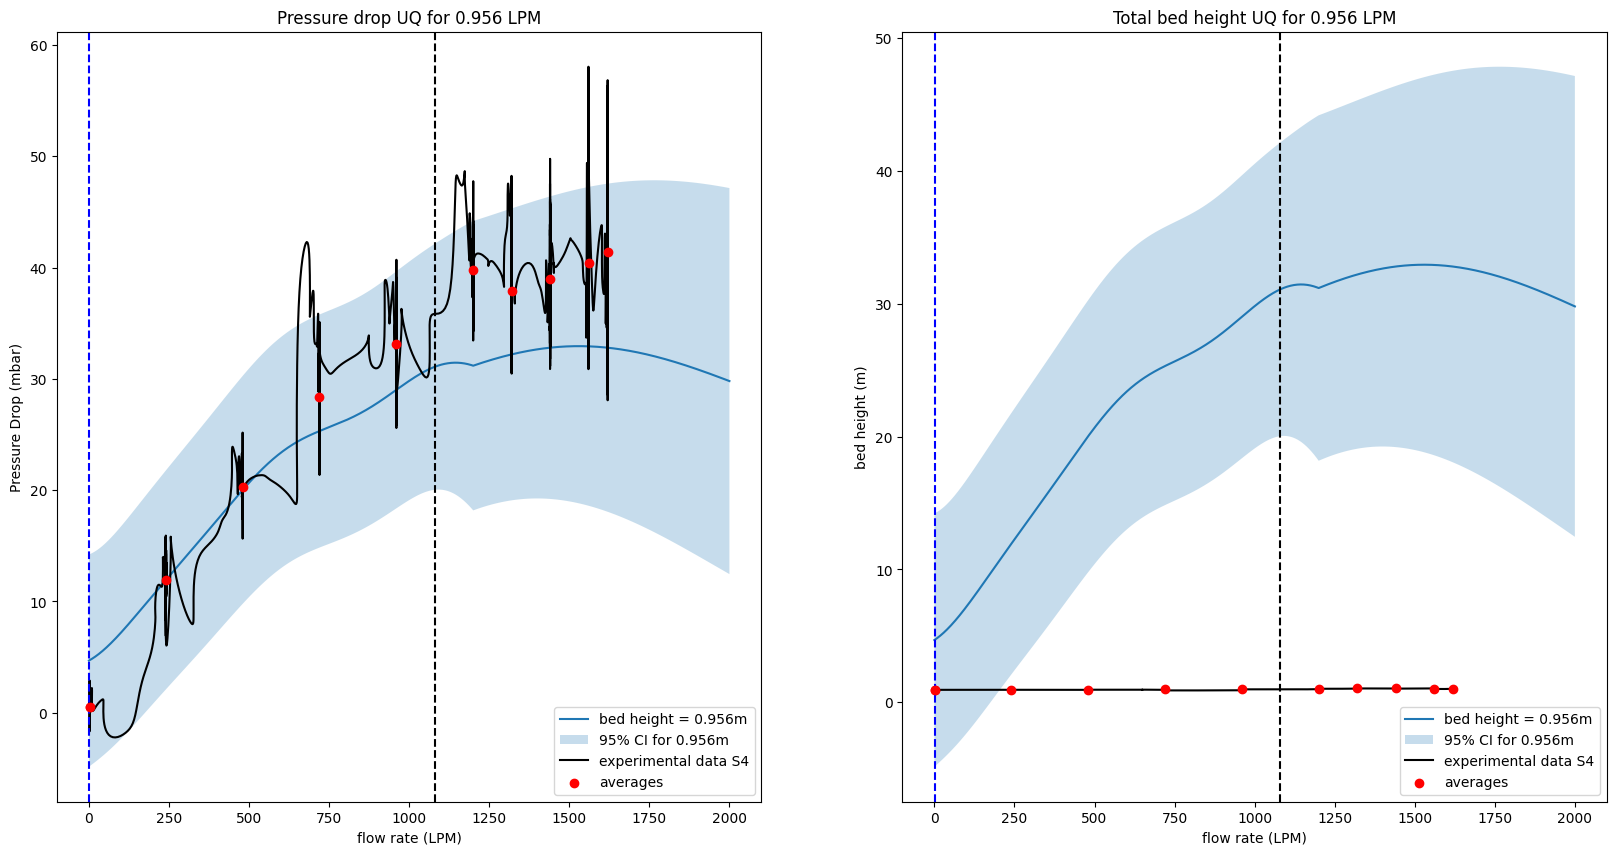

In [ ]:
fig, chart = plt.subplots(1, 2)

for dp in bed_values:
    xdat = np.hstack(
        [flowrate_range, np.ones(num_pred + 300).reshape(num_pred + 300, 1) * dp]
    )
    print(xdat.shape)
    ydat, std_dat = descaler_gp(
        GP.predict(scaler(xdat, mean_X, std_X), return_std=True), mean_y, std_y
    )

    UQ_u = ydat + 1.96 * std_dat
    UQ_l = ydat - 1.96 * std_dat

    chart[0].plot(2 * xdat[:, 0], ydat, label=f"bed height = {dp}m")
    if n_bed_heights <= 4:
        chart[0].fill_between(
            2 * xdat[:, 0],
            UQ_u,
            UQ_l,
            alpha=0.25,
            label=f"95% CI for {dp}m",
        )

    chart[1].plot(2 * xdat[:, 0], ydat, label=f"bed height = {dp}m")
    if n_bed_heights <= 4:
        chart[1].fill_between(
            2 * xdat[:, 0],
            UQ_u[:, 1],
            UQ_l[:, 1],
            alpha=0.25,
            label=f"95% CI for {dp}m",
        )

chart[0].plot(
    metrics["flowrate_combi"],
    metrics["p1"],
    color="black",
    label="experimental data S4",
)
chart[1].plot(
    metrics["flowrate_combi"],
    metrics["total_bed_height"],
    color="black",
    label="experimental data S4",
)

for seg in segments:
    chart[0].scatter(seg["flowrate_combi"], seg["p1"], c="red", zorder=3)
    chart[1].scatter(seg["flowrate_combi"], seg["total_bed_height"], c="red", zorder=3)

chart[0].scatter(
    segments[0]["flowrate_combi"],
    segments[0]["p1"],
    c="red",
    label="averages",
)
chart[1].scatter(
    segments[0]["flowrate_combi"],
    segments[0]["total_bed_height"],
    c="red",
    label="averages",
)

fig.set_figheight(10)
fig.set_figwidth(20)

chart[0].axvline(X[:, 0].max(), linestyle="--", color="black")
chart[0].axvline(X[:, 0].min(), linestyle="--", color="blue")

chart[1].axvline(X[:, 0].max(), linestyle="--", color="black")
chart[1].axvline(X[:, 0].min(), linestyle="--", color="blue")
chart[0].legend()
chart[1].legend()
chart[0].set_xlabel("flow rate (LPM)")
chart[1].set_xlabel("flow rate (LPM)")
chart[1].set_ylabel("bed height (m)")
chart[0].set_ylabel("Pressure Drop (mbar)")

chart[0].set_title("Pressure drop UQ for 0.956 LPM")
chart[1].set_title("Total bed height UQ for 0.956 LPM")